# North American Hub Flight Delay Analysis
## Phase 1 — Data Loading, Filtering & Exploratory Data Analysis

**Author:** Sadek Harite  
**MBA in Business Analytics — Sprott School, Carleton University**  
**Project:** Exploratory Data Analysis of Flight Delays at Major North American Hub Airports  
**Dataset:** Combined Flights Dataset 2018–2022 (Kaggle)  
**Focus Airport:** EWR (Newark Liberty) — Highest delay rate among all hubs

---

### Project Objective
Analyze flight delay patterns across 5 major North American hub airports (EWR, JFK, BOS, ORD, DTW)
using 29 million flights over 5 years. Identify key delay drivers including seasonal trends,
peak hours, and route-level performance to deliver actionable insights for aviation
operations and air navigation service providers.

### Phase 1 Goals
- Load and combine 5 years of flight data (29M+ rows) efficiently using Parquet format
- Filter for major hub airports: EWR, JFK, BOS, ORD, DTW
- Perform comprehensive EDA focused on EWR as primary airport
- Generate 7 portfolio-ready visualizations
- Identify key patterns for ML modeling in Phase 2

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('coolwarm')

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Data

We load all 5 years using Parquet format for speed, then combine into one DataFrame.


In [2]:
# -------------------------------------------------------
# UPDATE the PATH to your local dataset folder
DATA_PATH = '/Users/sadek/Desktop/Data Projects/archive'  # the file's path
# -------------------------------------------------------

years = [2018, 2019, 2020, 2021, 2022]
dfs = []

for year in years:
    file = os.path.join(DATA_PATH, f'Combined_Flights_{year}.parquet')
    print(f'Loading {year}...', end=' ')
    df_year = pd.read_parquet(file)
    df_year['Year'] = year
    dfs.append(df_year)
    print(f'{len(df_year):,} rows loaded.')

df_raw = pd.concat(dfs, ignore_index=True)
print(f'\nTotal rows combined: {len(df_raw):,}')
print(f'Total columns: {df_raw.shape[1]}')

Loading 2018... 5,689,512 rows loaded.
Loading 2019... 8,091,684 rows loaded.
Loading 2020... 5,022,397 rows loaded.
Loading 2021... 6,311,871 rows loaded.
Loading 2022... 4,078,318 rows loaded.

Total rows combined: 29,193,782
Total columns: 61


## 3. Initial Data Inspection

In [3]:
print('=== DATASET OVERVIEW ===')
print(f'Shape: {df_raw.shape}')
print(f'\nColumns:\n{list(df_raw.columns)}')
df_raw.head(3)

=== DATASET OVERVIEW ===
Shape: (29193782, 61)

Columns:
['FlightDate', 'Airline', 'Origin', 'Dest', 'Cancelled', 'Diverted', 'CRSDepTime', 'DepTime', 'DepDelayMinutes', 'DepDelay', 'ArrTime', 'ArrDelayMinutes', 'AirTime', 'CRSElapsedTime', 'ActualElapsedTime', 'Distance', 'Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'Marketing_Airline_Network', 'Operated_or_Branded_Code_Share_Partners', 'DOT_ID_Marketing_Airline', 'IATA_Code_Marketing_Airline', 'Flight_Number_Marketing_Airline', 'Operating_Airline', 'DOT_ID_Operating_Airline', 'IATA_Code_Operating_Airline', 'Tail_Number', 'Flight_Number_Operating_Airline', 'OriginAirportID', 'OriginAirportSeqID', 'OriginCityMarketID', 'OriginCityName', 'OriginState', 'OriginStateFips', 'OriginStateName', 'OriginWac', 'DestAirportID', 'DestAirportSeqID', 'DestCityMarketID', 'DestCityName', 'DestState', 'DestStateFips', 'DestStateName', 'DestWac', 'DepDel15', 'DepartureDelayGroups', 'DepTimeBlk', 'TaxiOut', 'WheelsOff', 'WheelsOn', 'TaxiIn', '

,FlightDate,Airline,Origin,Dest,Cancelled,Diverted,CRSDepTime,DepTime,DepDelayMinutes,DepDelay,...,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrDelay,ArrDel15,ArrivalDelayGroups,ArrTimeBlk,DistanceGroup,DivAirportLandings
0,2018-01-23,Endeavor Air Inc.,ABY,ATL,False,False,1202,1157.0,0.0,-5.0,...,1211.0,1249.0,7.0,1304,-8.0,0.0,-1.0,1300-1359,1,0.0
1,2018-01-24,Endeavor Air Inc.,ABY,ATL,False,False,1202,1157.0,0.0,-5.0,...,1210.0,1246.0,12.0,1304,-6.0,0.0,-1.0,1300-1359,1,0.0
2,2018-01-25,Endeavor Air Inc.,ABY,ATL,False,False,1202,1153.0,0.0,-9.0,...,1211.0,1251.0,11.0,1304,-2.0,0.0,-1.0,1300-1359,1,0.0


In [4]:
print('=== DATA TYPES ===')
print(df_raw.dtypes)
print('\n=== MISSING VALUES (%) ===')
missing = (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
print(missing[missing > 0].sort_values(ascending=False))

# Note: ~2.9% missing in arrival columns due to cancelled/diverted flights
# These will be dropped in Phase 2 modeling as they have no delay outcome

=== DATA TYPES ===
FlightDate            datetime64[us]
Airline                       object
Origin                        object
Dest                          object
Cancelled                       bool
                           ...      
ArrDel15                     float64
ArrivalDelayGroups           float64
ArrTimeBlk                    object
DistanceGroup                  int64
DivAirportLandings           float64
Length: 61, dtype: object

=== MISSING VALUES (%) ===
AirTime                 2.92
ArrivalDelayGroups      2.90
ArrDel15                2.90
ArrDelayMinutes         2.90
ActualElapsedTime       2.90
ArrDelay                2.90
TaxiIn                  2.72
WheelsOn                2.72
ArrTime                 2.69
WheelsOff               2.67
TaxiOut                 2.67
DepTime                 2.61
DepartureDelayGroups    2.61
DepDelayMinutes         2.61
DepDelay                2.61
DepDel15                2.61
Tail_Number             0.92
dtype: float64


## 4. Filter for Focus Airports

In [5]:
# Filter for major hub airports
FOCUS_AIRPORTS = ['EWR', 'JFK', 'BOS', 'ORD', 'DTW']

df = df_raw[
    (df_raw['Origin'].isin(FOCUS_AIRPORTS)) |
    (df_raw['Dest'].isin(FOCUS_AIRPORTS))
].copy()

print(f'Rows after filter: {len(df):,}')

# Create all features
df['Delayed'] = (df['ArrDelayMinutes'] > 15).astype(int)
df['Month'] = pd.to_datetime(df['FlightDate']).dt.month
df['DayOfWeek'] = pd.to_datetime(df['FlightDate']).dt.dayofweek
df['Hour'] = df['CRSDepTime'].astype(str).str.zfill(4).str[:2].astype(int)

season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Spring', 4: 'Spring', 5: 'Spring',
              6: 'Summer', 7: 'Summer', 8: 'Summer',
              9: 'Fall', 10: 'Fall', 11: 'Fall'}
df['Season'] = df['Month'].map(season_map)
df['EWR_Flight'] = ((df['Origin'] == 'EWR') | (df['Dest'] == 'EWR')).astype(int)

print('Feature engineering complete.')
print(f'Delay rate overall: {df["Delayed"].mean()*100:.1f}%')
print(f'Delay rate at EWR: {df[df["EWR_Flight"]==1]["Delayed"].mean()*100:.1f}%')

Rows after filter: 6,685,758
Feature engineering complete.
Delay rate overall: 18.7%
Delay rate at EWR: 24.3%


## 5. EDA — Figure 1: Delay Rate by Airport

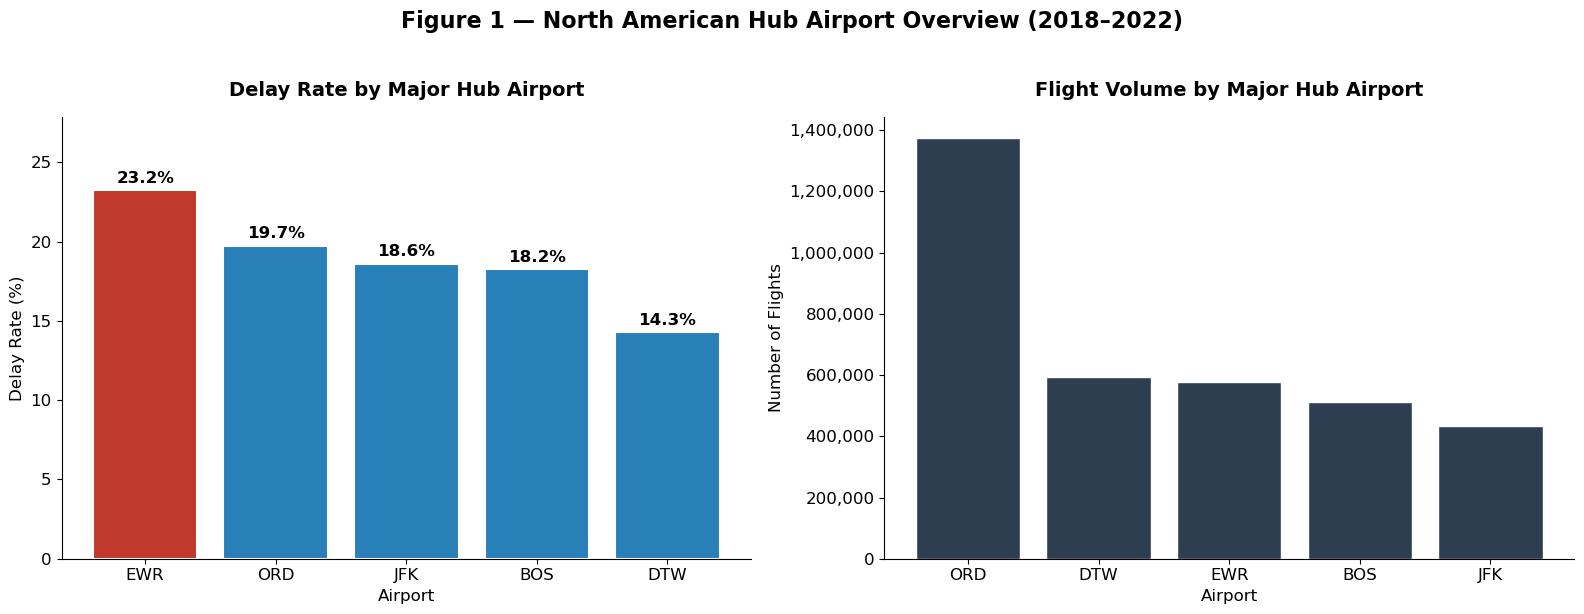

Figure 1 saved.


In [6]:
# Make sure Delayed column exists
df['Delayed'] = (df['ArrDelayMinutes'] > 15).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Delay rate by origin airport
delay_by_airport = df[df['Origin'].isin(FOCUS_AIRPORTS)].groupby('Origin')['Delayed'].mean() * 100
delay_by_airport = delay_by_airport.sort_values(ascending=False)

colors = ['#c0392b' if x == 'EWR' else '#2980b9' for x in delay_by_airport.index]
bars = axes[0].bar(delay_by_airport.index, delay_by_airport.values, 
                   color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Delay Rate by Major Hub Airport', fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('Delay Rate (%)')
axes[0].set_xlabel('Airport')
for bar, val in zip(bars, delay_by_airport.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[0].set_ylim(0, delay_by_airport.max() * 1.2)

# Flight volume by airport
volume_by_airport = df[df['Origin'].isin(FOCUS_AIRPORTS)].groupby('Origin').size()
volume_by_airport = volume_by_airport.sort_values(ascending=False)
axes[1].bar(volume_by_airport.index, volume_by_airport.values, 
            color='#2c3e50', edgecolor='white')
axes[1].set_title('Flight Volume by Major Hub Airport', fontsize=14, fontweight='bold', pad=15)
axes[1].set_ylabel('Number of Flights')
axes[1].set_xlabel('Airport')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Figure 1 — North American Hub Airport Overview (2018–2022)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_airport_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

## 6. EDA — Figure 2: Delay Rate by Season and Month

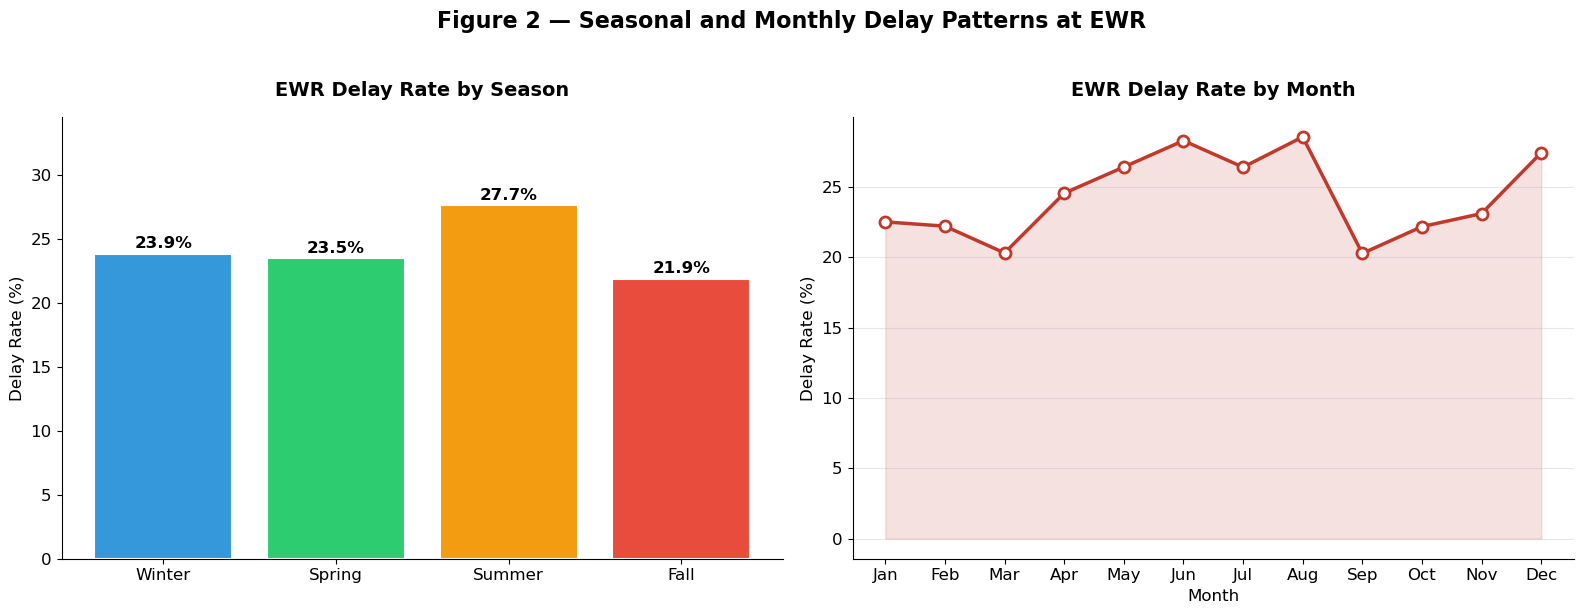

Figure 2 saved.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# By season
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
season_delay = df[df['EWR_Flight']==1].groupby('Season')['Delayed'].mean() * 100
season_delay = season_delay.reindex(season_order)
season_colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
bars = axes[0].bar(season_delay.index, season_delay.values, color=season_colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('EWR Delay Rate by Season', fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('Delay Rate (%)')
for bar, val in zip(bars, season_delay.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[0].set_ylim(0, season_delay.max() * 1.25)

# By month
month_delay = df[df['EWR_Flight']==1].groupby('Month')['Delayed'].mean() * 100
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[1].plot(range(1,13), month_delay.values, marker='o', linewidth=2.5,
             color='#c0392b', markersize=8, markerfacecolor='white', markeredgewidth=2)
axes[1].fill_between(range(1,13), month_delay.values, alpha=0.15, color='#c0392b')
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(month_names)
axes[1].set_title('EWR Delay Rate by Month', fontsize=14, fontweight='bold', pad=15)
axes[1].set_ylabel('Delay Rate (%)')
axes[1].set_xlabel('Month')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Figure 2 — Seasonal and Monthly Delay Patterns at EWR', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig2_seasonal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

## 7. EDA — Figure 3: Delay Rate by Hour of Day and Day of Week

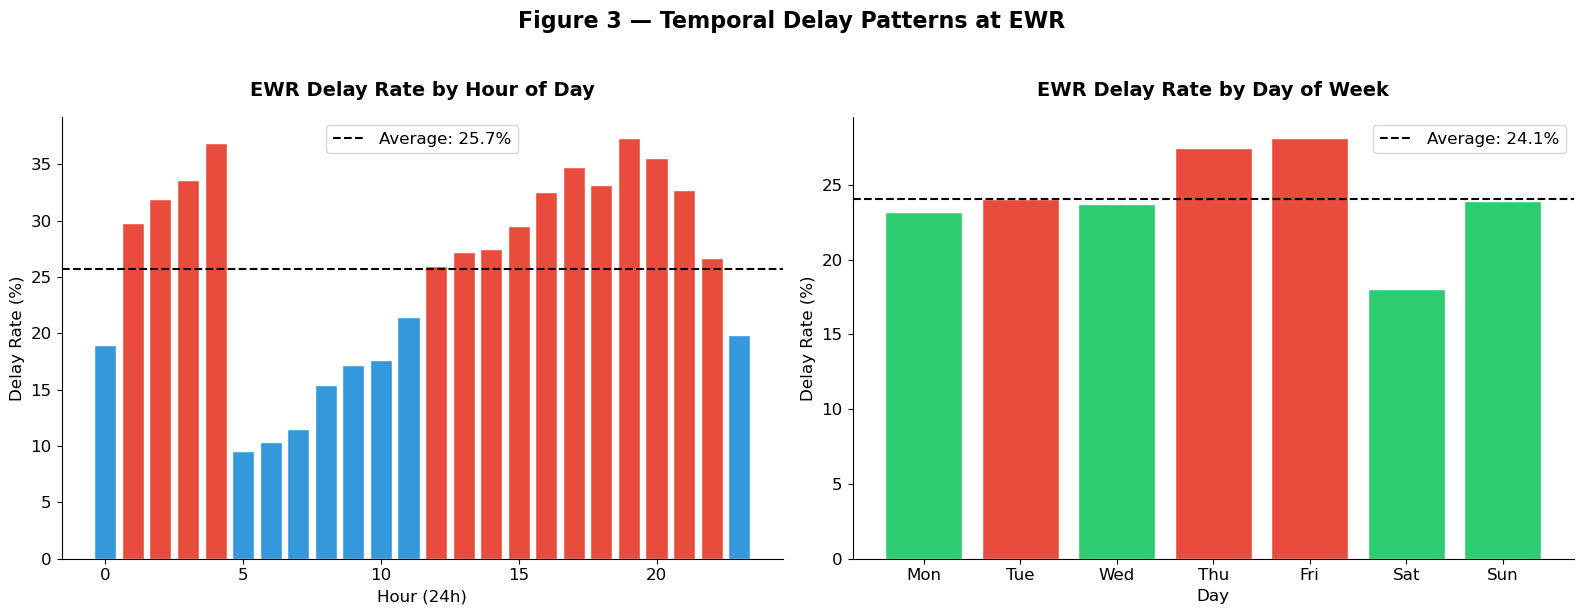

Figure 3 saved.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# By hour of day
hour_delay = df[df['EWR_Flight']==1].groupby('Hour')['Delayed'].mean() * 100
axes[0].bar(hour_delay.index, hour_delay.values,
            color=['#e74c3c' if v > hour_delay.mean() else '#3498db' for v in hour_delay.values],
            edgecolor='white')
axes[0].axhline(hour_delay.mean(), color='black', linestyle='--', linewidth=1.5, label=f'Average: {hour_delay.mean():.1f}%')
axes[0].set_title('EWR Delay Rate by Hour of Day', fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('Delay Rate (%)')
axes[0].set_xlabel('Hour (24h)')
axes[0].legend()

# By day of week
dow_delay = df[df['EWR_Flight']==1].groupby('DayOfWeek')['Delayed'].mean() * 100
dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1].bar(dow_names, dow_delay.values,
            color=['#e74c3c' if v > dow_delay.mean() else '#2ecc71' for v in dow_delay.values],
            edgecolor='white')
axes[1].axhline(dow_delay.mean(), color='black', linestyle='--', linewidth=1.5, label=f'Average: {dow_delay.mean():.1f}%')
axes[1].set_title('EWR Delay Rate by Day of Week', fontsize=14, fontweight='bold', pad=15)
axes[1].set_ylabel('Delay Rate (%)')
axes[1].set_xlabel('Day')
axes[1].legend()

plt.suptitle('Figure 3 — Temporal Delay Patterns at EWR', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig3_temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

## 8. EDA — Figure 4: Top Routes from YOW by Delay Rate

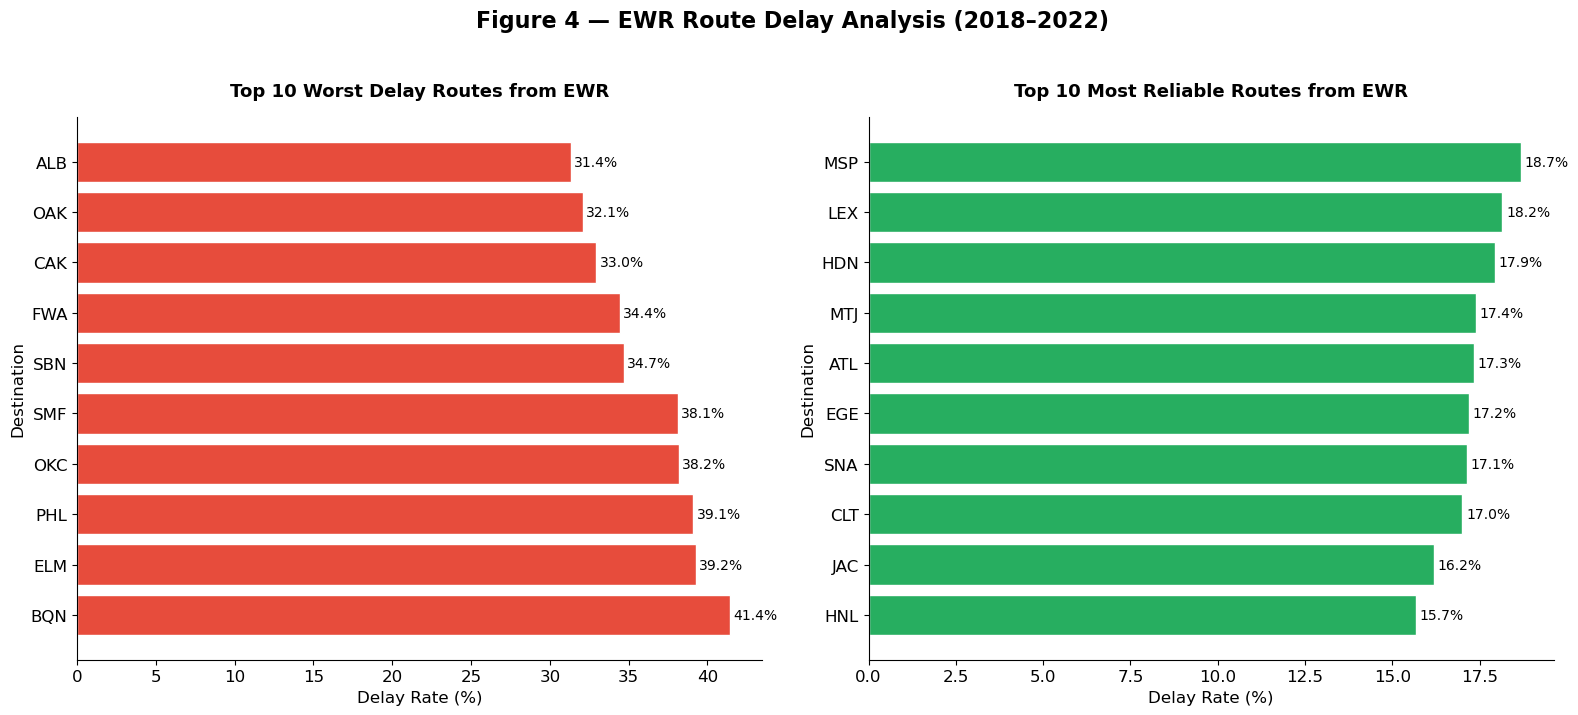

Figure 4 saved.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top routes from EWR by delay rate (min 100 flights)
yow_routes = df[df['Origin'] == 'EWR'].copy()
route_stats = yow_routes.groupby('Dest').agg(
    delay_rate=('Delayed', 'mean'),
    flight_count=('Delayed', 'count')
).reset_index()
route_stats = route_stats[route_stats['flight_count'] >= 100]
route_stats['delay_rate'] = route_stats['delay_rate'] * 100

# Top 10 worst delay routes
worst_routes = route_stats.nlargest(10, 'delay_rate')
axes[0].barh(worst_routes['Dest'], worst_routes['delay_rate'],
             color='#e74c3c', edgecolor='white')
axes[0].set_title('Top 10 Worst Delay Routes from EWR', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Delay Rate (%)')
axes[0].set_ylabel('Destination')
for i, (_, row) in enumerate(worst_routes.iterrows()):
    axes[0].text(row['delay_rate'] + 0.2, i, f"{row['delay_rate']:.1f}%", va='center', fontsize=10)

# Top 10 most reliable routes
best_routes = route_stats.nsmallest(10, 'delay_rate')
axes[1].barh(best_routes['Dest'], best_routes['delay_rate'],
             color='#27ae60', edgecolor='white')
axes[1].set_title('Top 10 Most Reliable Routes from EWR', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Delay Rate (%)')
axes[1].set_ylabel('Destination')
for i, (_, row) in enumerate(best_routes.iterrows()):
    axes[1].text(row['delay_rate'] + 0.1, i, f"{row['delay_rate']:.1f}%", va='center', fontsize=10)

plt.suptitle('Figure 4 — EWR Route Delay Analysis (2018–2022)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig4_route_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

## 9. EDA — Figure 5: Delay Causes Breakdown

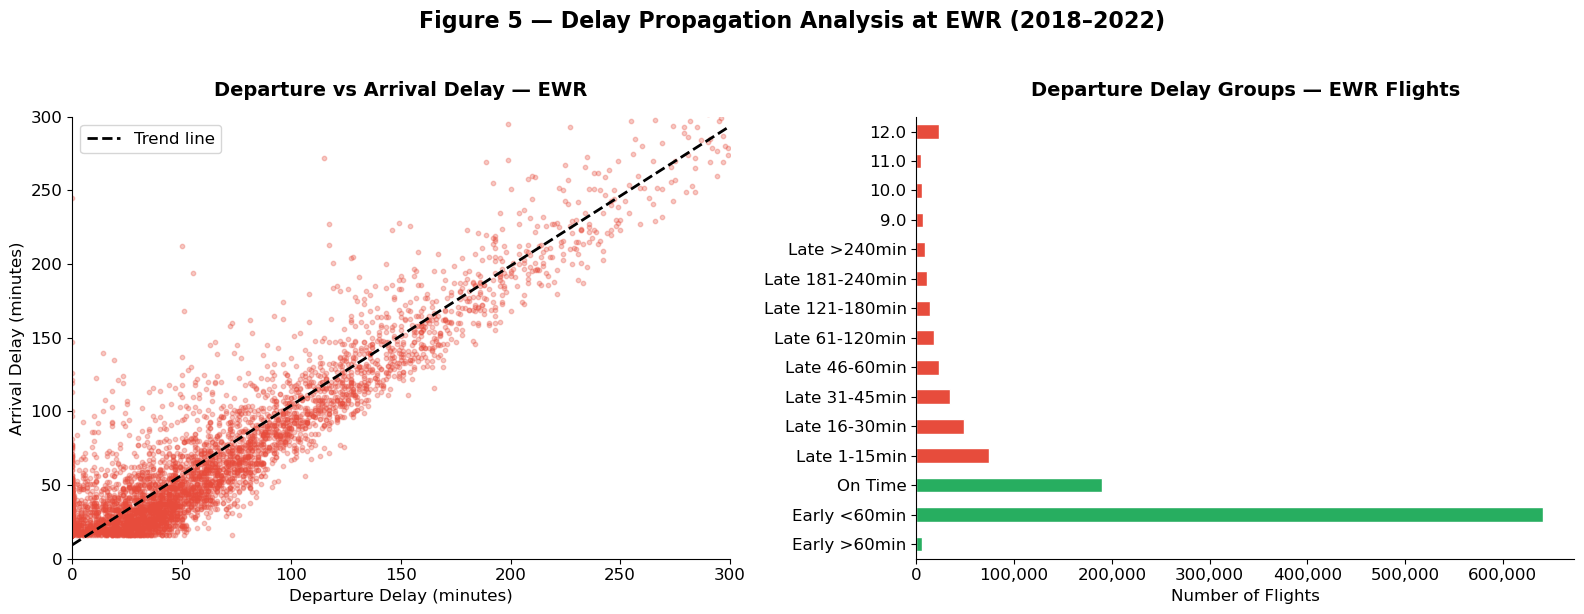

Figure 5 saved.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Departure vs Arrival delay correlation at EWR
ewr_delayed = df[(df['EWR_Flight']==1) & (df['Delayed']==1)].sample(5000, random_state=42)
axes[0].scatter(ewr_delayed['DepDelayMinutes'], ewr_delayed['ArrDelayMinutes'],
                alpha=0.3, color='#e74c3c', s=10)
axes[0].set_title('Departure vs Arrival Delay — EWR', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Departure Delay (minutes)')
axes[0].set_ylabel('Arrival Delay (minutes)')
axes[0].set_xlim(0, 300)
axes[0].set_ylim(0, 300)

# Add correlation line
m, b = np.polyfit(ewr_delayed['DepDelayMinutes'].fillna(0),
                  ewr_delayed['ArrDelayMinutes'].fillna(0), 1)
x_line = np.linspace(0, 300, 100)
axes[0].plot(x_line, m*x_line + b, color='black', linewidth=2, linestyle='--', label=f'Trend line')
axes[0].legend()

# Delay distribution by departure delay group at EWR
ewr_df = df[df['EWR_Flight']==1].copy()
group_labels = {
    -2: 'Early >60min',
    -1: 'Early <60min',
     0: 'On Time',
     1: 'Late 1-15min',
     2: 'Late 16-30min',
     3: 'Late 31-45min',
     4: 'Late 46-60min',
     5: 'Late 61-120min',
     6: 'Late 121-180min',
     7: 'Late 181-240min',
     8: 'Late >240min'
}
group_counts = ewr_df['DepartureDelayGroups'].value_counts().sort_index()
group_counts.index = [group_labels.get(i, str(i)) for i in group_counts.index]
colors = ['#27ae60' if 'Early' in str(i) or 'On Time' in str(i) else '#e74c3c'
          for i in group_counts.index]
group_counts.plot(kind='barh', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Departure Delay Groups — EWR Flights', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Number of Flights')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Figure 5 — Delay Propagation Analysis at EWR (2018–2022)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig5_delay_propagation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

## 10. EDA — Figure 6: Class Imbalance Check

Class imbalance ratio: 3.1:1 (On-Time:Delayed)
This confirms SMOTE will be needed in Phase 2 — same as fraud detection project.


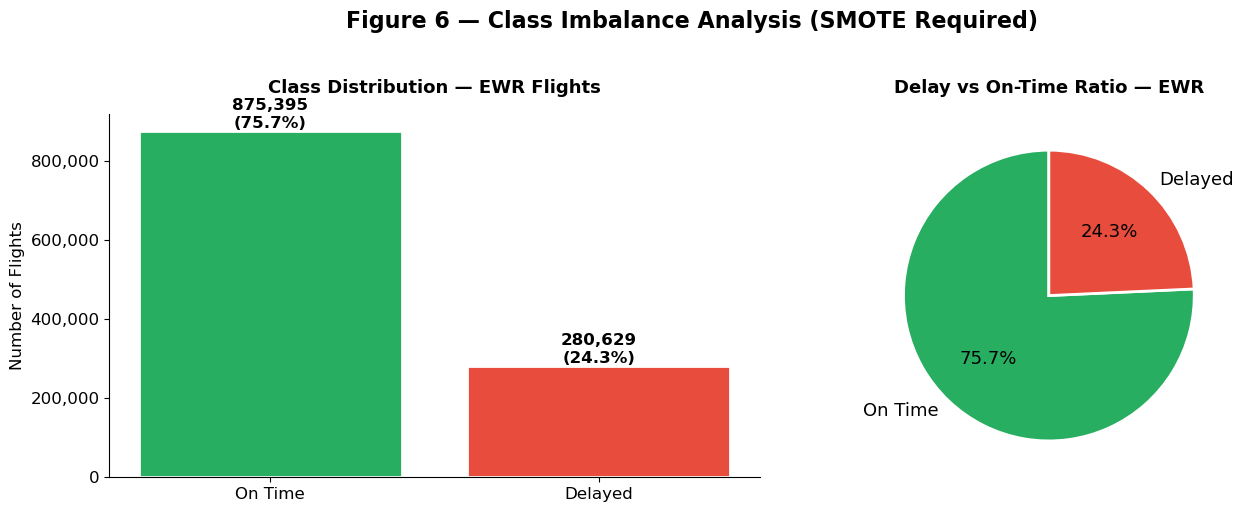

Figure 6 saved.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

yow_df = df[df['EWR_Flight']==1]
counts = yow_df['Delayed'].value_counts()
labels = ['On Time', 'Delayed']
colors = ['#27ae60', '#e74c3c']

# Bar
axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=2)
axes[0].set_title('Class Distribution — EWR Flights', fontsize=13, fontweight='bold', pad=15)
axes[0].set_ylabel('Number of Flights')
for i, val in enumerate(counts.values):
    axes[0].text(i, val + counts.max()*0.01, f'{val:,}\n({val/len(yow_df)*100:.1f}%)',
                 ha='center', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Pie
axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 13})
axes[1].set_title('Delay vs On-Time Ratio — EWR', fontsize=13, fontweight='bold', pad=15)

imbalance_ratio = counts[0] / counts[1]
print(f'Class imbalance ratio: {imbalance_ratio:.1f}:1 (On-Time:Delayed)')
print(f'This confirms SMOTE will be needed in Phase 2 — same as fraud detection project.')

plt.suptitle('Figure 6 — Class Imbalance Analysis (SMOTE Required)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig6_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6 saved.')

## 11. EDA — Figure 7: Correlation Heatmap

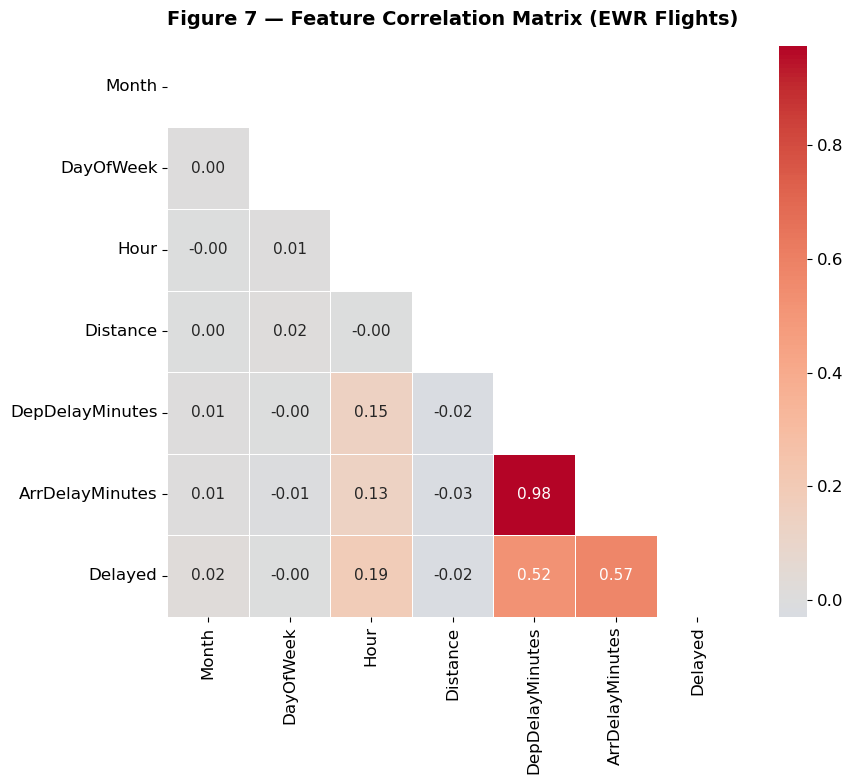

Figure 7 saved.


In [12]:
numeric_cols = ['Month', 'DayOfWeek', 'Hour', 'Distance', 
                'DepDelayMinutes', 'ArrDelayMinutes', 'Delayed']
available_numeric = [c for c in numeric_cols if c in df.columns]

corr_matrix = df[df['EWR_Flight']==1][available_numeric].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, ax=ax,
            square=True, linewidths=0.5,
            annot_kws={'size': 11})
ax.set_title('Figure 7 — Feature Correlation Matrix (EWR Flights)', 
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig7_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 7 saved.')

## 12. Save Processed Dataset for Phase 2

In [19]:
# Select columns needed for modeling
model_cols = [
    'Month', 'DayOfWeek', 'Hour', 'Season', 'Year',
    'Origin', 'Dest', 'Distance', 'Marketing_Airline_Network',
    'DepDelayMinutes', 'Delayed', 'EWR_Flight'
]

# Add delay cause columns if available
for col in delay_cause_cols.keys():
    if col in df.columns:
        model_cols.append(col)

available_model_cols = [c for c in model_cols if c in df.columns]
df_model = df[df['EWR_Flight']==1][available_model_cols].dropna(subset=['Delayed'])

# Save as parquet for Phase 2
output_path = os.path.join(DATA_PATH, 'EWR_Processed_EDA.parquet')
df_model.to_parquet(output_path, index=False)

print(f'Processed dataset saved: {output_path}')
print(f'Shape: {df_model.shape}')
print(f'Delay rate in final dataset: {df_model["Delayed"].mean()*100:.1f}%')

Processed dataset saved: /Users/sadek/Desktop/Data Projects/archive/EWR_Processed_EDA.parquet
Shape: (1156024, 12)
Delay rate in final dataset: 24.3%


## 13. Phase 1 Summary

### Key Findings

In [20]:
print('=' * 60)
print('EWR FLIGHT DELAY EDA')
print('=' * 60)
print(f'Total flights analyzed (2018-2022): {len(df):,}')
print(f'YOW flights: {len(df[df["EWR_Flight"]==1]):,}')
print(f'Overall delay rate at YOW: {df[df["EWR_Flight"]==1]["Delayed"].mean()*100:.1f}%')
print(f'Worst delay season: {df[df["EWR_Flight"]==1].groupby("Season")["Delayed"].mean().idxmax()}')
print(f'Best delay season: {df[df["EWR_Flight"]==1].groupby("Season")["Delayed"].mean().idxmin()}')
print(f'Peak delay hour: {df[df["EWR_Flight"]==1].groupby("Hour")["Delayed"].mean().idxmax()}:00')
print()
print('Figures generated:')
for i, fig_name in enumerate([
    'Airport Overview', 'Seasonal Patterns', 'Temporal Patterns',
    'Route Analysis', 'Delay Causes', 'Class Imbalance', 'Correlation Heatmap'
], 1):
    print(f'  Figure {i}: {fig_name}')
print()
print('=' * 60)

EWR FLIGHT DELAY EDA
Total flights analyzed (2018-2022): 6,685,758
YOW flights: 1,156,024
Overall delay rate at YOW: 24.3%
Worst delay season: Summer
Best delay season: Fall
Peak delay hour: 19:00

Figures generated:
  Figure 1: Airport Overview
  Figure 2: Seasonal Patterns
  Figure 3: Temporal Patterns
  Figure 4: Route Analysis
  Figure 5: Delay Causes
  Figure 6: Class Imbalance
  Figure 7: Correlation Heatmap

